In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
(28, 28)
5


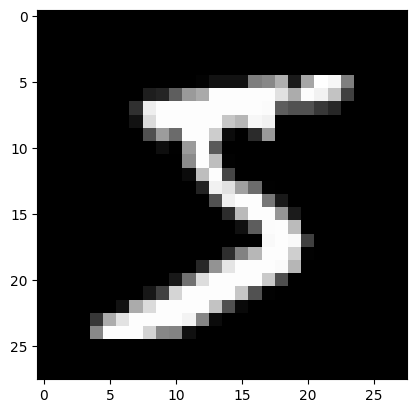

In [26]:
dataset = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = dataset.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print(X_train[0].shape)
plt.imshow(X_train[0], cmap='gray')
print(y_train[0])
X_train=X_train/255.0
X_test=X_test/255.0

In [27]:
X_train_flat=X_train.reshape(X_train.shape[0], 28*28)
print(X_train_flat.shape)
X_test_flat=X_test.reshape(X_test.shape[0], 28*28)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


In [110]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout


In [152]:
model=Sequential([
    Dense(128, activation='relu', input_shape=(28*28,), kernel_regularizer=tf.keras.regularizers.l2(0.002)),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.002)),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

/Users/priyanshnandan/Codes/ML/NeuralNetworks/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [153]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='adam', metrics=['accuracy'])

In [154]:
model.fit(X_train_flat,y_train, epochs=10)

Epoch 1/10


/Users/priyanshnandan/Codes/ML/NeuralNetworks/venv/lib/python3.13/site-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 782us/step - accuracy: 0.8906 - loss: 0.6185
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 813us/step - accuracy: 0.9357 - loss: 0.3848
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - accuracy: 0.9416 - loss: 0.3461
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step - accuracy: 0.9463 - loss: 0.3244
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 777us/step - accuracy: 0.9468 - loss: 0.3175
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 783us/step - accuracy: 0.9502 - loss: 0.3043
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - accuracy: 0.9495 - loss: 0.3016
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 783us/step - accuracy: 0.9506 - loss: 0.2989
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 827us/step - accuracy: 0.9512 - loss: 0.2964
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - accuracy: 0.9519 - loss: 0.2912


In [155]:
predictions=model.predict(X_test_flat)
print(predictions[0])
print(np.argmax(predictions[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step
[2.07229423e-05 9.23884090e-06 1.04608494e-04 3.70190857e-04
 4.56609854e-07 1.31526222e-05 1.50484503e-09 9.98493612e-01
 1.24916119e-06 9.86871077e-04]
7


In [156]:
model.evaluate(X_test_flat, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - accuracy: 0.9676 - loss: 0.2383


[0.23828935623168945, 0.9675999879837036]

0


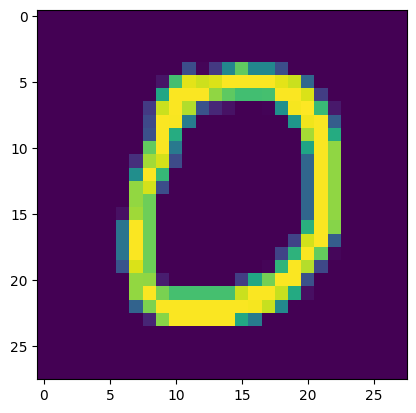

In [157]:
plt.imshow(X_test[10])
print(y_test[10])


In [158]:
predict=model.predict(X_test_flat[10].reshape(1, 28*28))
print(np.argmax(predict[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
0


(28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2


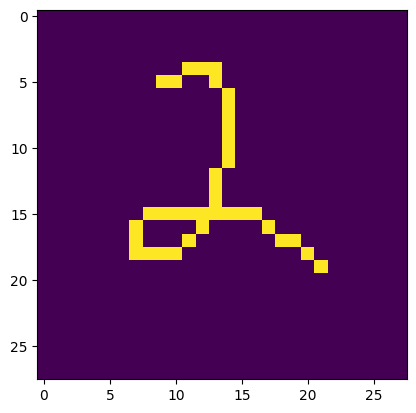

In [163]:
img=cv2.imread('Handwritten_digits/images/sample12.png', cv2.IMREAD_GRAYSCALE)
print(img.shape)
plt.imshow(img)
img=img/255.0
img_flat=img.reshape(1, 28*28)
predict=model.predict(img_flat)
print(np.argmax(predict))

In [53]:
os.getcwd()

'/Users/priyanshnandan/Codes/ML/NeuralNetworks'